In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('fraud_oracle.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [ ]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [ ]:
df.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [ ]:
!pip install missingno

<Axes: >

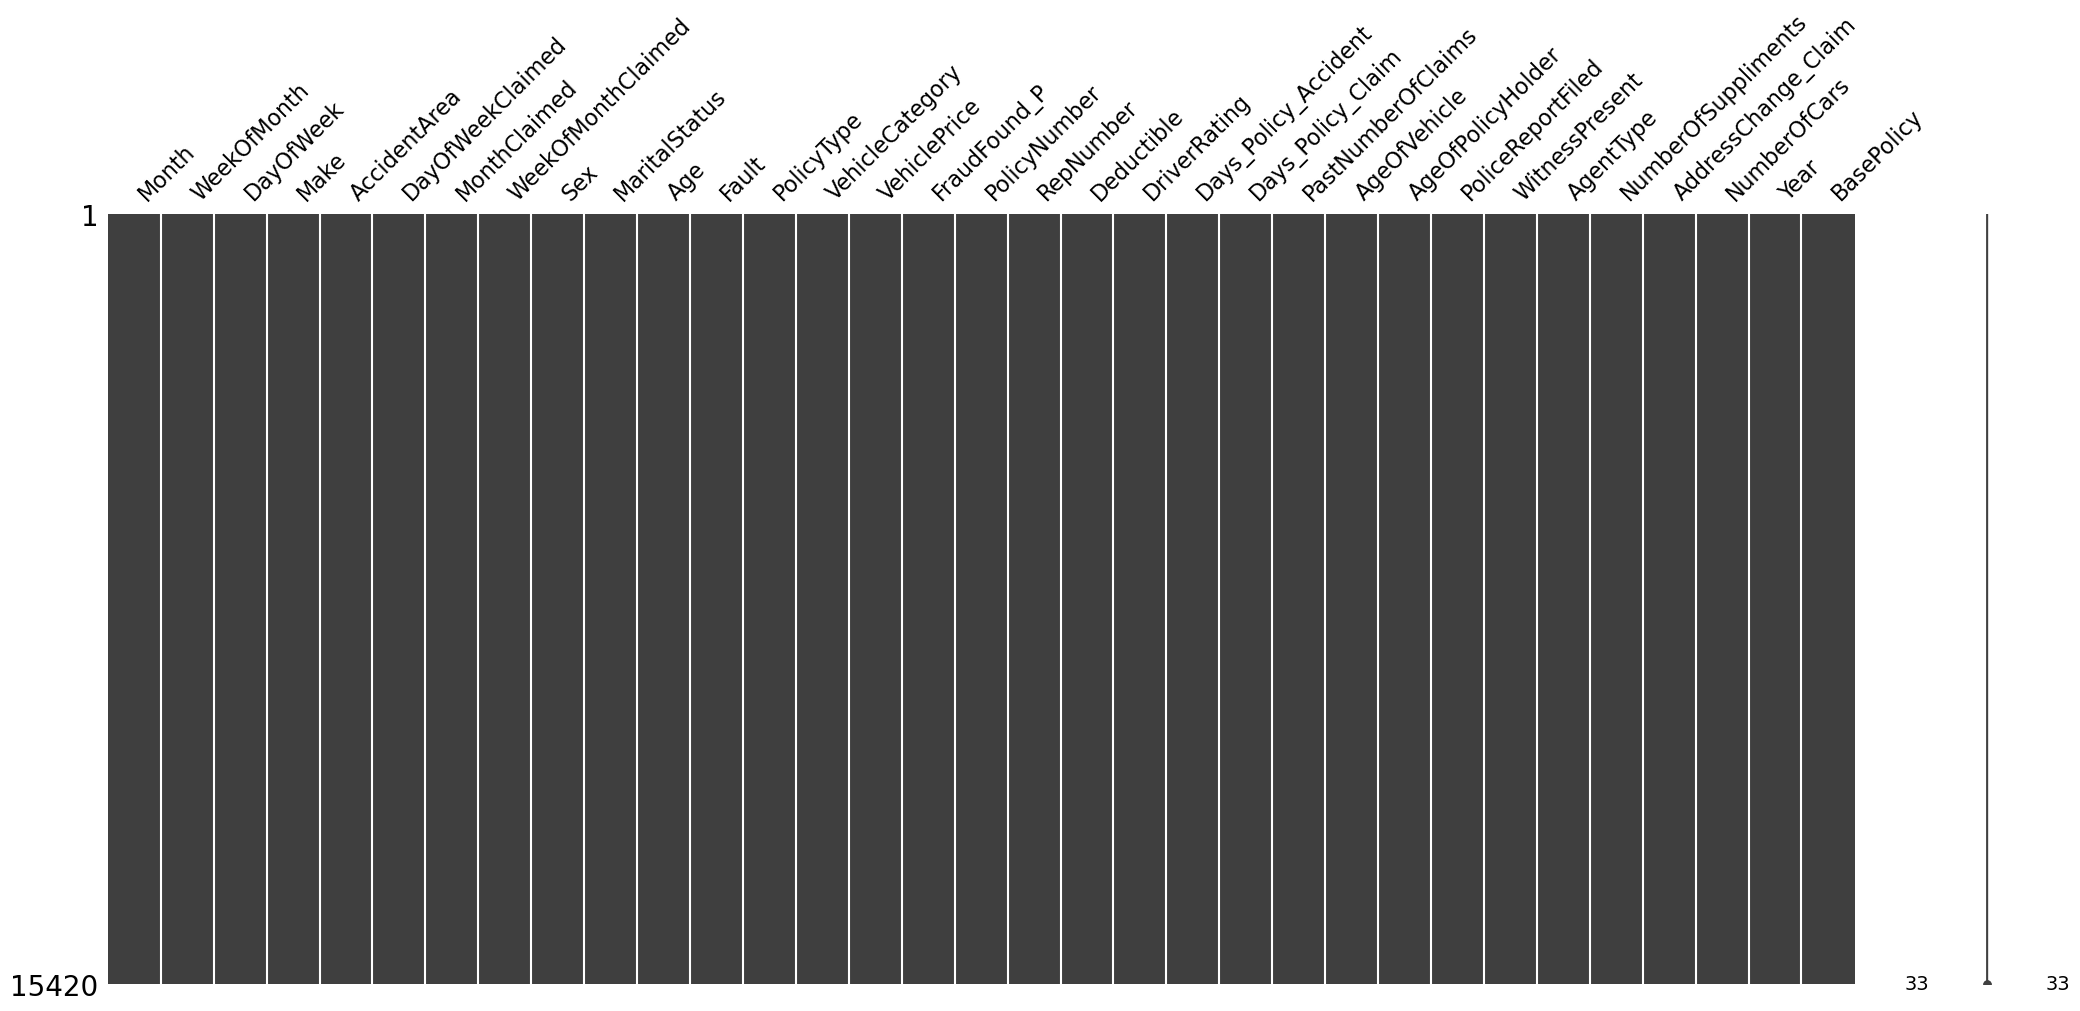

In [ ]:
import missingno as ms
ms.matrix(df)

In [ ]:
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

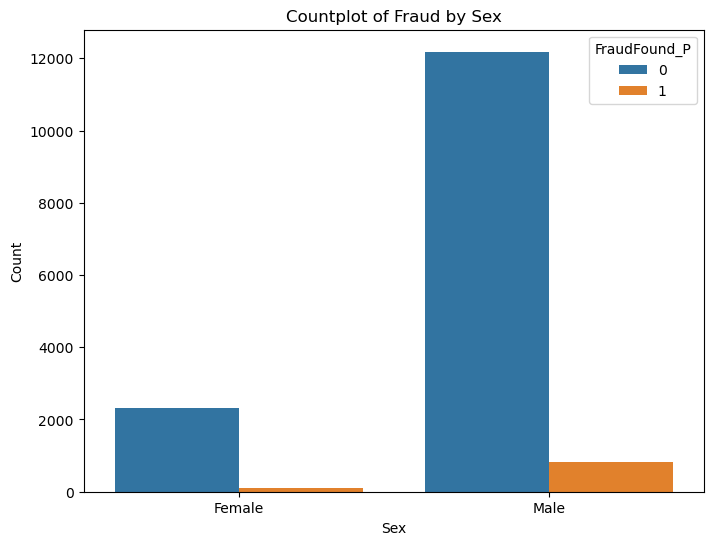

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='FraudFound_P', data=df)
plt.title('Countplot of Fraud by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='FraudFound_P')
plt.show()

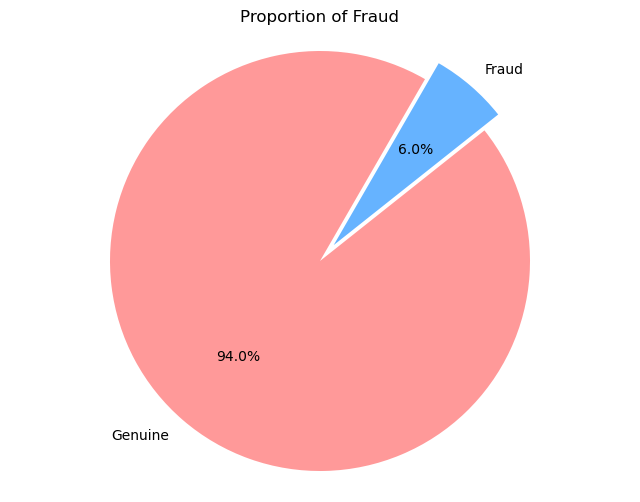

In [ ]:
fraud_counts = df['FraudFound_P'].value_counts()
fraud_labels = ['Genuine', 'Fraud']
fraud_colors = ['#ff9999','#66b3ff']
plt.figure(figsize=(8, 6))
plt.pie(fraud_counts, labels=fraud_labels,
        colors=fraud_colors, autopct='%1.1f%%',
        startangle=60,explode = (0.1, 0))
plt.title('Proportion of Fraud')
plt.axis('equal')
plt.show()

C:\Users\ajesh\AppData\Local\Temp\ipykernel_20000\3335302121.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True,cmap='viridis', fmt='.3f', cbar_kws={'label': 'Values'})


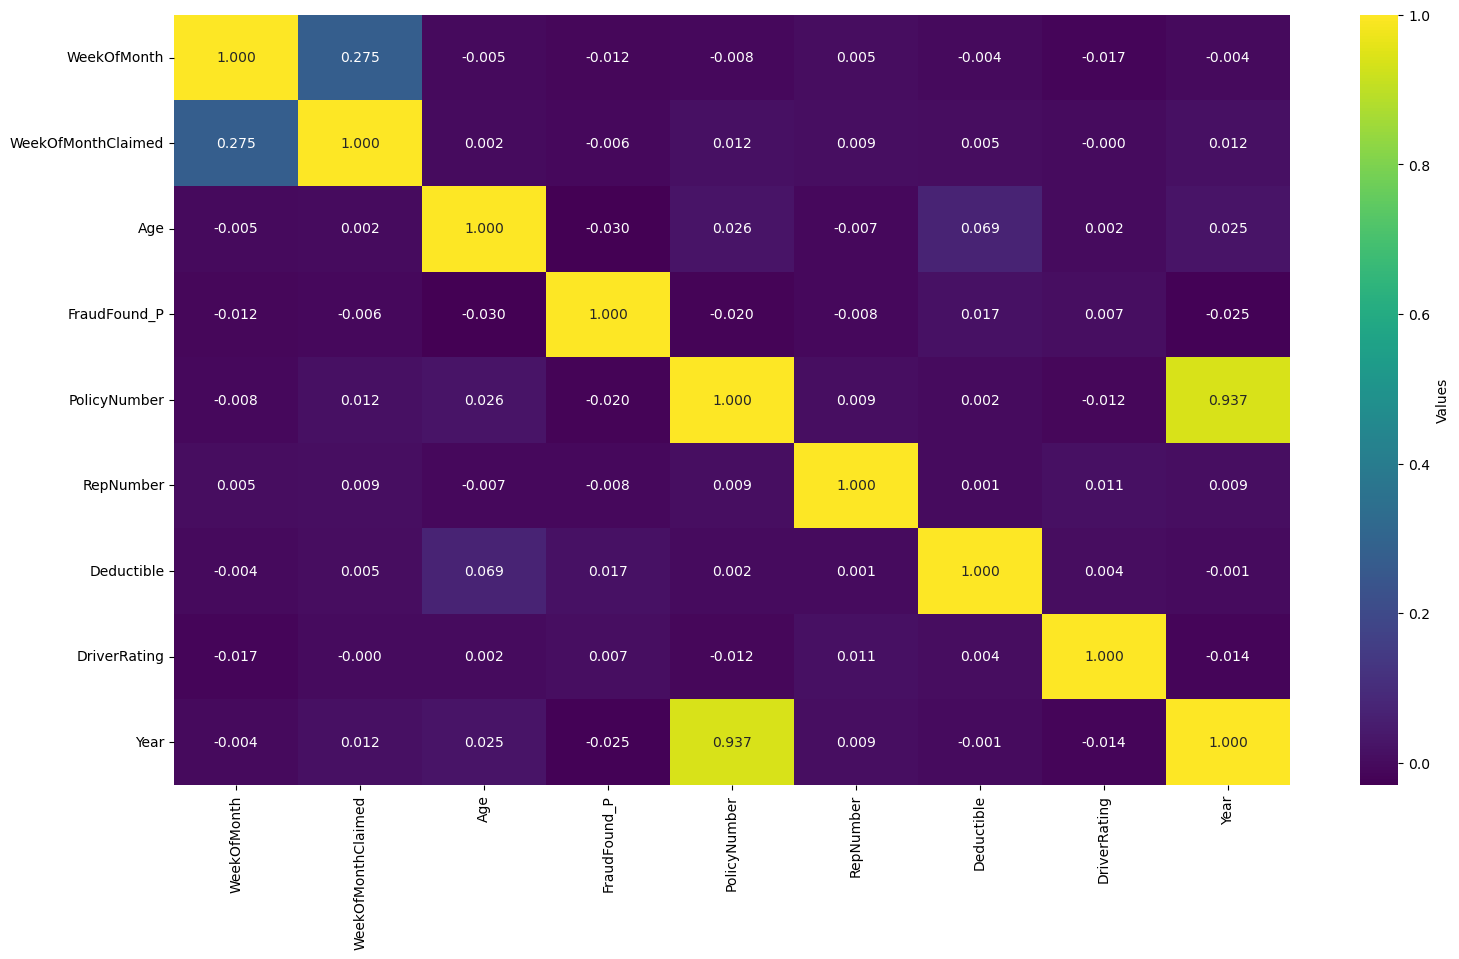

In [ ]:
plt.figure(figsize=(18,10))
sns.heatmap(df.corr(), annot=True,cmap='viridis', fmt='.3f', cbar_kws={'label': 'Values'})
plt.show()

<Axes: >

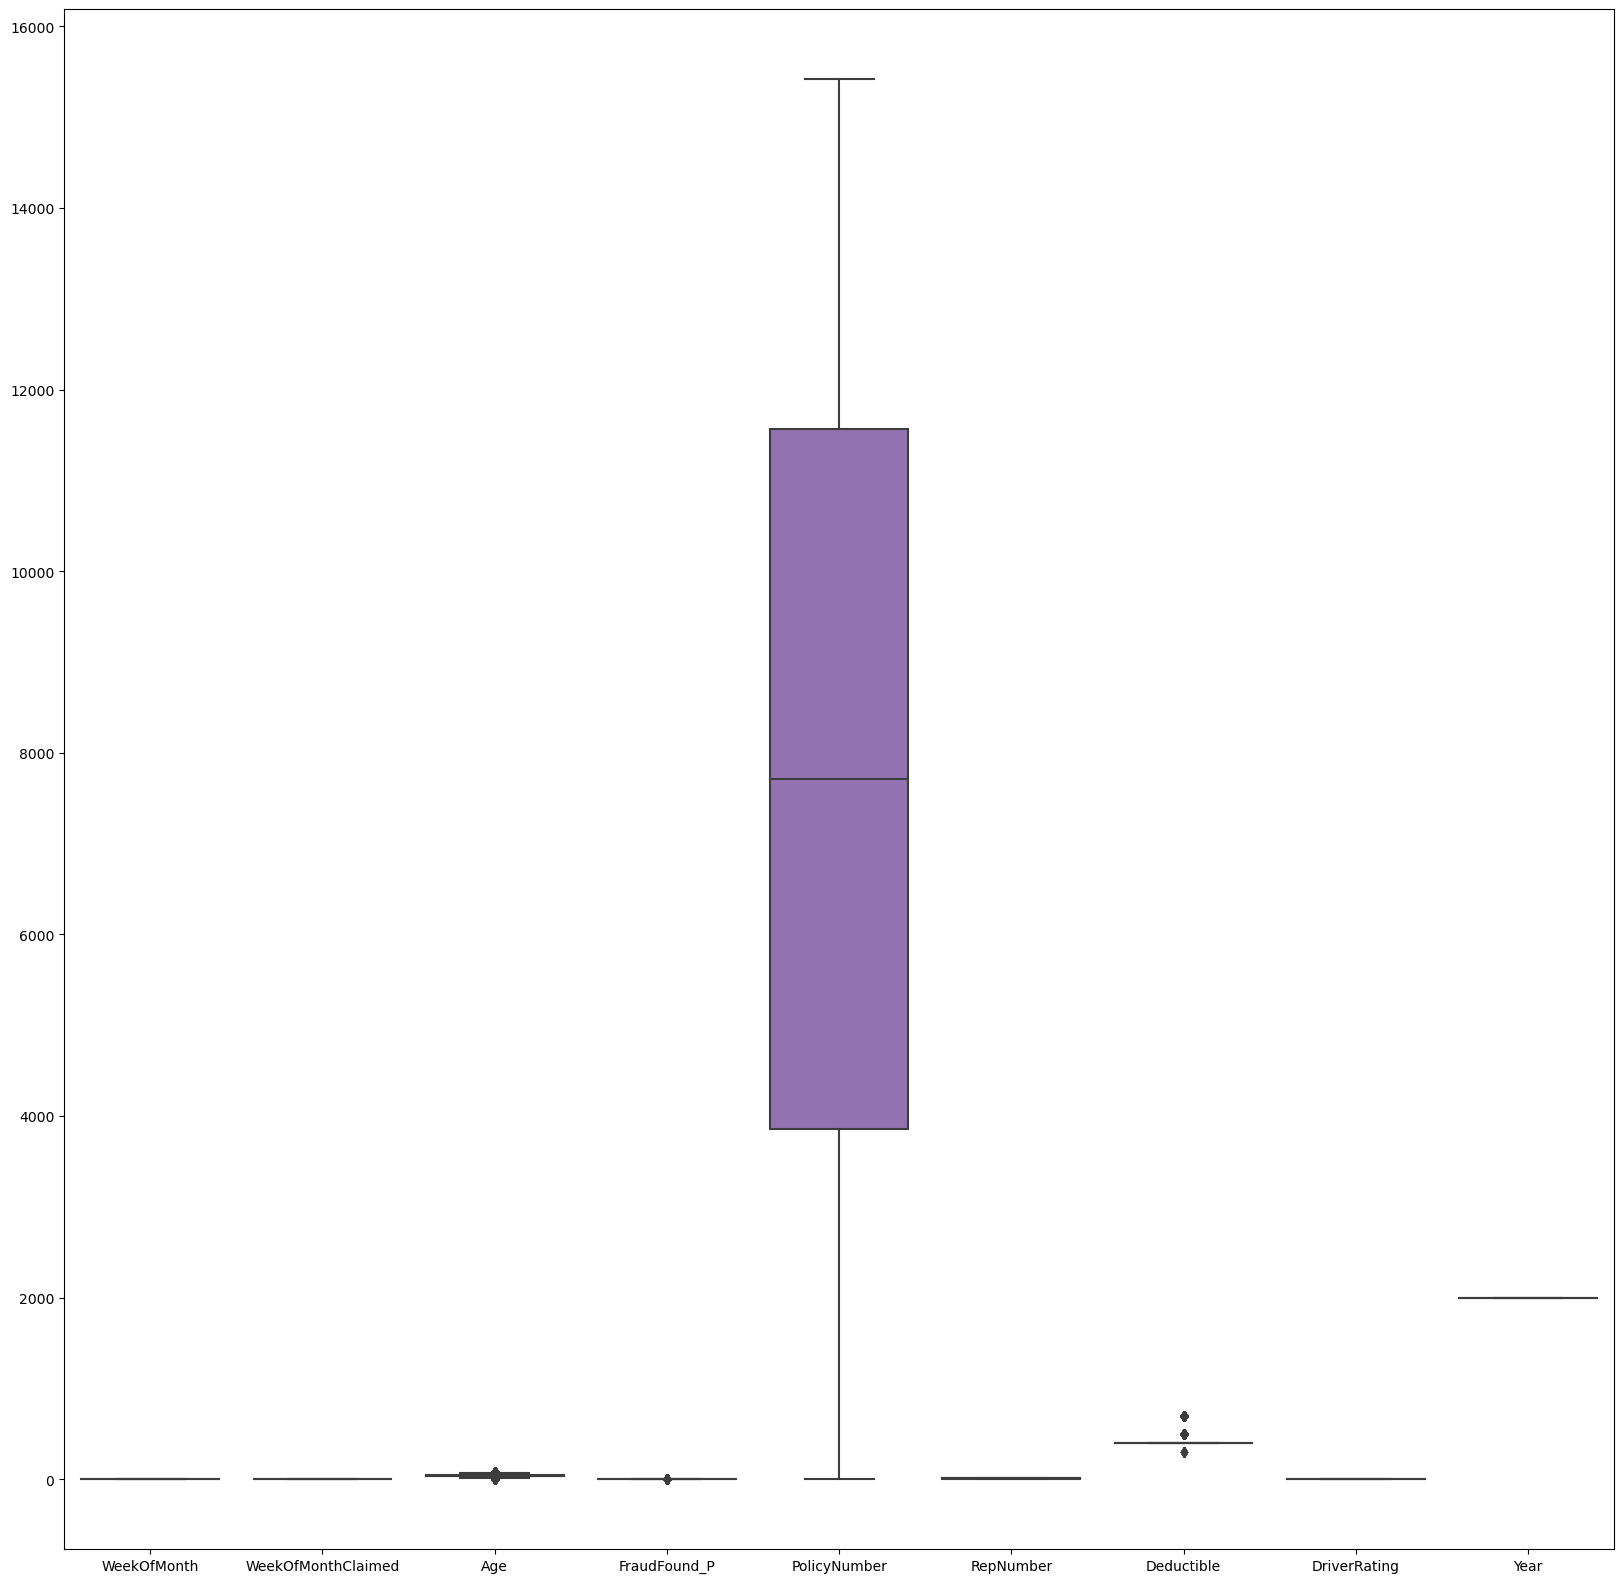

In [ ]:
plt.figure(figsize=(20,20))
sns.boxplot(df)

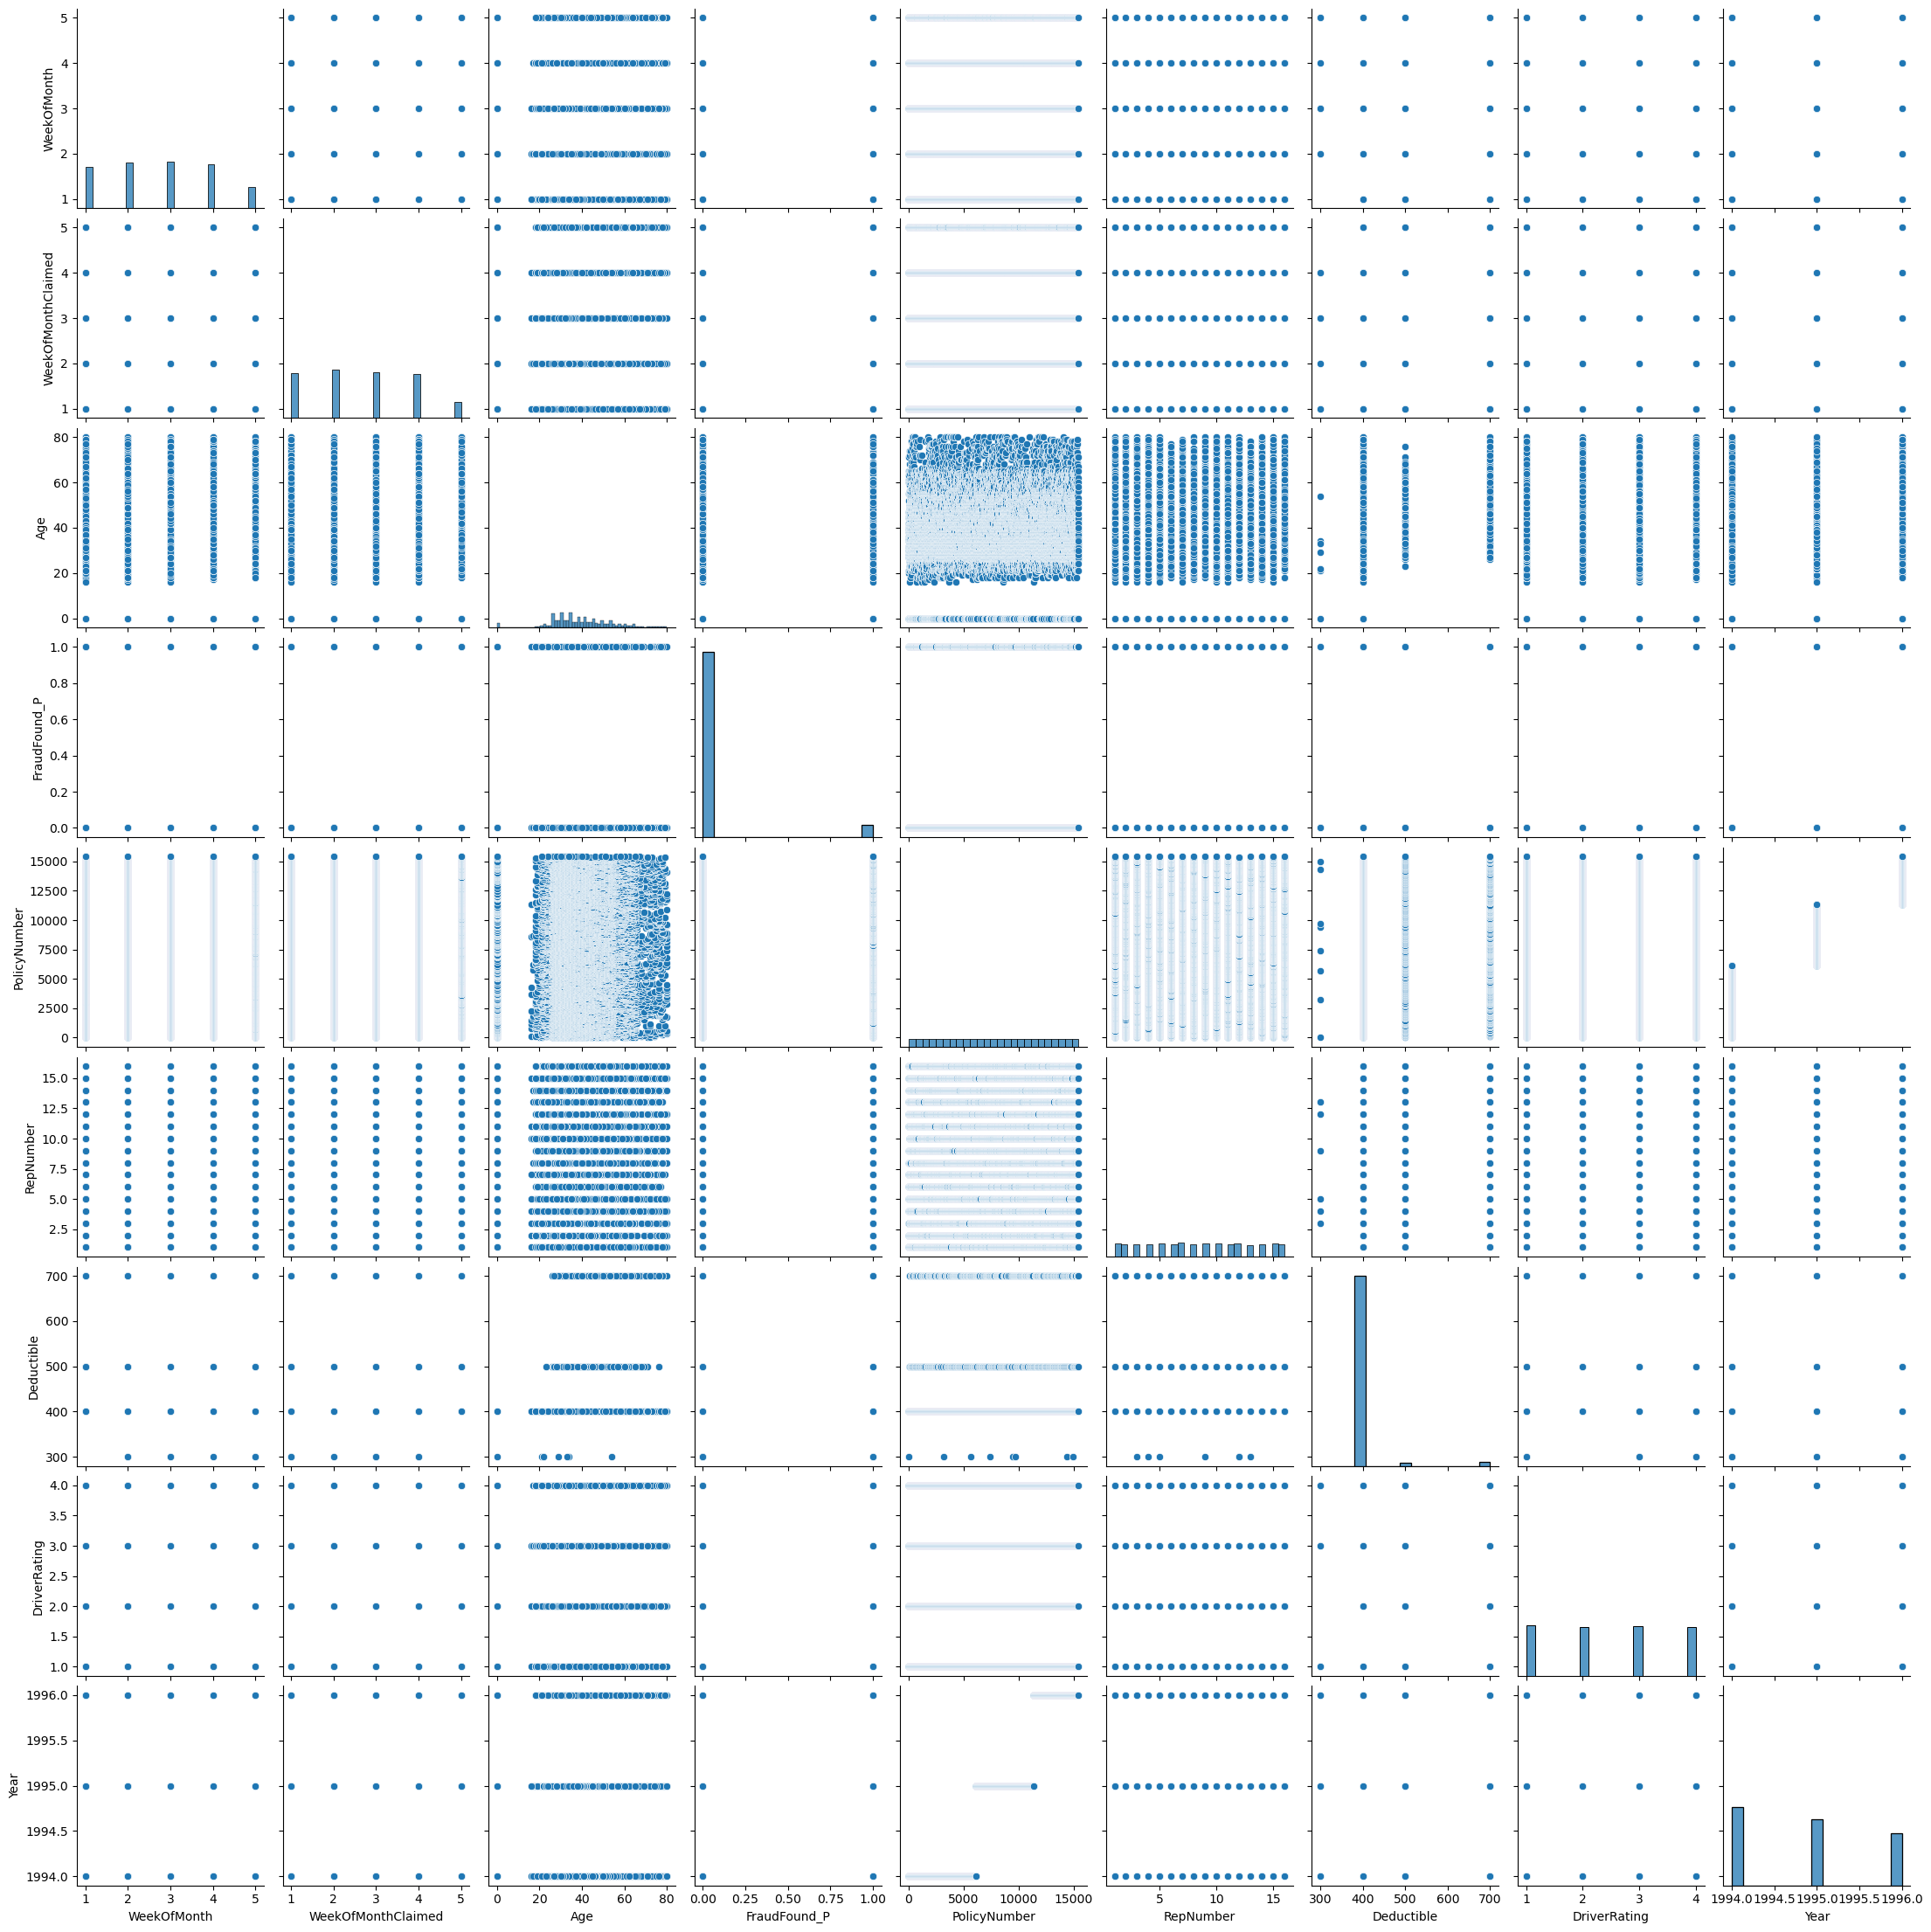

In [ ]:
sns.pairplot(df)

In [ ]:
count_of_1 = df['FraudFound_P'].value_counts()[1]
print("Count of 1 in FoundFraud_P:", count_of_1)

Count of 1 in FoundFraud_P: 923


In [ ]:
count_of_0 = df['FraudFound_P'].value_counts()[0]
print("Count of 1 in FoundFraud_P:", count_of_0)

Count of 1 in FoundFraud_P: 14497


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for c in df.columns:
    if df[c].dtypes=='object':
        df[c]=le.fit_transform(df[c])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  int32
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  int32
 3   Make                  15420 non-null  int32
 4   AccidentArea          15420 non-null  int32
 5   DayOfWeekClaimed      15420 non-null  int32
 6   MonthClaimed          15420 non-null  int32
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  int32
 9   MaritalStatus         15420 non-null  int32
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  int32
 12  PolicyType            15420 non-null  int32
 13  VehicleCategory       15420 non-null  int32
 14  VehiclePrice          15420 non-null  int32
 15  FraudFound_P          15420 non-null  int64
 16  Poli

In [ ]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,2,5,6,6,1,6,5,1,0,2,...,1,3,0,0,0,3,0,2,1994,2
1,4,3,6,6,1,2,5,4,1,2,...,4,4,1,0,0,3,3,0,1994,1
2,10,5,0,6,1,5,10,2,1,1,...,5,6,0,0,0,3,3,0,1994,1
3,6,2,2,17,0,1,6,1,1,1,...,6,7,1,0,0,2,3,0,1994,2
4,4,5,1,6,1,6,4,2,0,2,...,3,4,0,0,0,3,3,0,1994,1


In [ ]:
df.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [ ]:
x=df.drop(['FraudFound_P','PolicyNumber'],axis=1)
y=df['FraudFound_P']

In [ ]:
x.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'RepNumber', 'Deductible', 'DriverRating',
       'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
       'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled',
       'WitnessPresent', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy'],
      dtype='object')

In [ ]:
!pip install mlxtend

In [ ]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
dc=DecisionTreeClassifier()

In [ ]:
exhaustive_feature=EFS(dc,min_features=1,max_features=5,scoring='accuracy',cv=5)

In [ ]:
feature_selected=exhaustive_feature.fit(x_train,y_train)

Features: 203370/206367

In [ ]:
feature_selected.best_feature_names_

('Fault',
 'PolicyType',
 'AgeOfPolicyHolder',
 'AddressChange_Claim',
 'NumberOfCars')

In [ ]:
x_selected=df[['Fault',
 'PolicyType',
 'AgeOfPolicyHolder',
 'AddressChange_Claim',
 'NumberOfCars']]
y=df['FraudFound_P']

In [ ]:
x_selected.columns

Index(['Fault', 'PolicyType', 'AgeOfPolicyHolder', 'AddressChange_Claim',
       'NumberOfCars'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_selected,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
nb=GaussianNB()

In [ ]:
rf=RandomForestClassifier(n_estimators=100,
                         criterion="gini",
                         max_depth=None,
                         min_samples_split=2,
                         min_samples_leaf=1,
                         max_features="sqrt",
                         bootstrap=True,
                         random_state=None)

In [ ]:
boost=GradientBoostingClassifier(n_estimators=100,
                                learning_rate=0.1,
                                max_depth=3,
                                random_state=42)

In [ ]:
nb.fit(x_train,y_train)
rf.fit(x_train,y_train)
boost.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
nb_predict=nb.predict(x_test)
rf_predict=rf.predict(x_test)
boost_predict=boost.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,ConfusionMatrixDisplay,confusion_matrix

In [ ]:
print('\nGaussian Naive Bayes\n')
print('Accuracy Score of Gaussian Naive Bayes =  ',accuracy_score(y_test,nb_predict))
print('\n')
print(classification_report(y_test,nb_predict))


Gaussian Naive Bayes

Accuracy Score of Gaussian Naive Bayes =   0.9121271076523995


              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2887
           1       0.11      0.05      0.07       197

    accuracy                           0.91      3084
   macro avg       0.52      0.51      0.51      3084
weighted avg       0.88      0.91      0.90      3084




Gaussian Naive Bayes



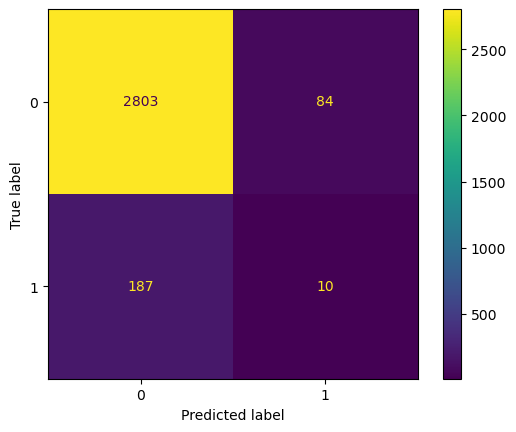

In [ ]:
print('\nGaussian Naive Bayes\n')
cms=ConfusionMatrixDisplay(confusion_matrix(y_test,nb_predict),display_labels=np.unique(y).tolist())
cms.plot()

In [ ]:
print('\nRandom Forest Classifier\n')
print('Accuracy Score of Random Forest Classifier =  ',accuracy_score(y_test,rf_predict))
print('\n')
print(classification_report(y_test,rf_predict))


Random Forest Classifier

Accuracy Score of Random Forest Classifier =   0.9393644617380026


              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2887
           1       0.86      0.06      0.11       197

    accuracy                           0.94      3084
   macro avg       0.90      0.53      0.54      3084
weighted avg       0.93      0.94      0.91      3084




Random Forest Classifier



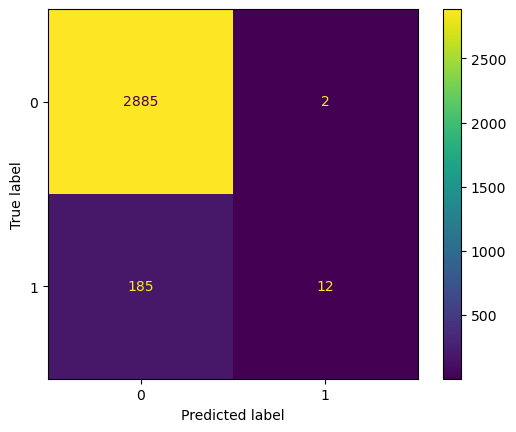

In [ ]:
print('\nRandom Forest Classifier\n')
cms=ConfusionMatrixDisplay(confusion_matrix(y_test,rf_predict),display_labels=np.unique(y).tolist())
cms.plot()

In [ ]:
print('\nGradient Boosting Classifier\n')
print('Accuracy Score of Gradient Boosting Classifier =  ',accuracy_score(y_test,boost_predict))
print('\n')
print(classification_report(y_test,boost_predict))


Gradient Boosting Classifier

Accuracy Score of Gradient Boosting Classifier =   0.938715953307393


              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2887
           1       0.90      0.05      0.09       197

    accuracy                           0.94      3084
   macro avg       0.92      0.52      0.53      3084
weighted avg       0.94      0.94      0.91      3084




Gradient Boosting Classifier



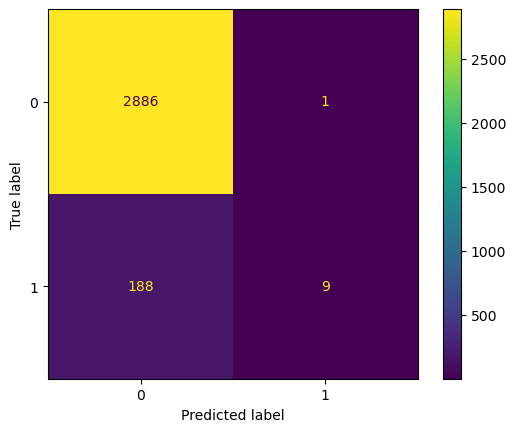

In [ ]:
print('\nGradient Boosting Classifier\n')
cms=ConfusionMatrixDisplay(confusion_matrix(y_test,boost_predict),display_labels=np.unique(y).tolist())
cms.plot()

In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [ ]:
model=Sequential()
model.add(Dense(units=33,activation="tanh",input_shape=(x_train.shape[1],)))
model.add(Dense(units=22,activation="tanh"))
model.add(Dense(units=14,activation="tanh"))
model.add(Dense(units=2,activation="tanh"))
model.add(Dense(units=1,activation="sigmoid"))

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 33)                198       
                                                                 
 dense_1 (Dense)             (None, 22)                748       
                                                                 
 dense_2 (Dense)             (None, 14)                322       
                                                                 
 dense_3 (Dense)             (None, 2)                 30        
                                                                 
 dense_4 (Dense)             (None, 1)                 3         
                                                                 
Total params: 1301 (5.08 KB)
Trainable params: 1301 (5.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
early_stop=EarlyStopping(monitor='loss',patience=10,verbose=0)

In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics='accuracy')

In [ ]:
model.fit(x_train,y_train,batch_size=32,epochs=100,callbacks=[early_stop])

Epoch 1/100


386/386 [==============================] - 4s 3ms/step - loss: 0.2329 - accuracy: 0.9364
Epoch 2/100
386/386 [==============================] - 1s 3ms/step - loss: 0.2171 - accuracy: 0.9411
Epoch 3/100
386/386 [==============================] - 1s 3ms/step - loss: 0.2091 - accuracy: 0.9411
Epoch 4/100
386/386 [==============================] - 1s 3ms/step - loss: 0.2025 - accuracy: 0.9411
Epoch 5/100
386/386 [==============================] - 2s 4ms/step - loss: 0.1995 - accuracy: 0.9411
Epoch 6/100
386/386 [==============================] - 2s 4ms/step - loss: 0.1972 - accuracy: 0.9411
Epoch 7/100
386/386 [==============================] - 1s 3ms/step - loss: 0.1942 - accuracy: 0.9411
Epoch 8/100
386/386 [==============================] - 1s 3ms/step - loss: 0.1940 - accuracy: 0.9411
Epoch 9/100
386/386 [==============================] - 1s 4ms/step - loss: 0.1921 - accuracy: 0.9411
Epoch 10/100
386/386 [==============================] - 1s 4ms/step - loss: 0.1922 - accu

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)

97/97 [==============================] - 1s 3ms/step - loss: 0.1866 - accuracy: 0.9384


In [ ]:
print("Accuracy Score of ANN using tensorflow = ",accuracy)

Accuracy Score of ANN using tensorflow =  0.9383916854858398


In [ ]:
nbac=accuracy_score(y_test,nb_predict)
rfac=accuracy_score(y_test,rf_predict)
boostac=accuracy_score(y_test,boost_predict)
annac=accuracy

In [ ]:
accuracy_scores = [nbac, rfac, boostac, annac]
labels = ['Gaussian Naive Bayes', 'Random Forest Classifier', 'Gradient Boosting Classifier', 'Artificial Neural Network']
custom_colors = ['#1b9e77', '#a9f971', '#fdaa48', '#6890F0']

In [ ]:
sorted_indices = sorted(range(len(accuracy_scores)), key=lambda i: accuracy_scores[i], reverse=True)
sorted_accuracy_scores = [accuracy_scores[i] for i in sorted_indices]
sorted_labels = [labels[i] for i in sorted_indices]

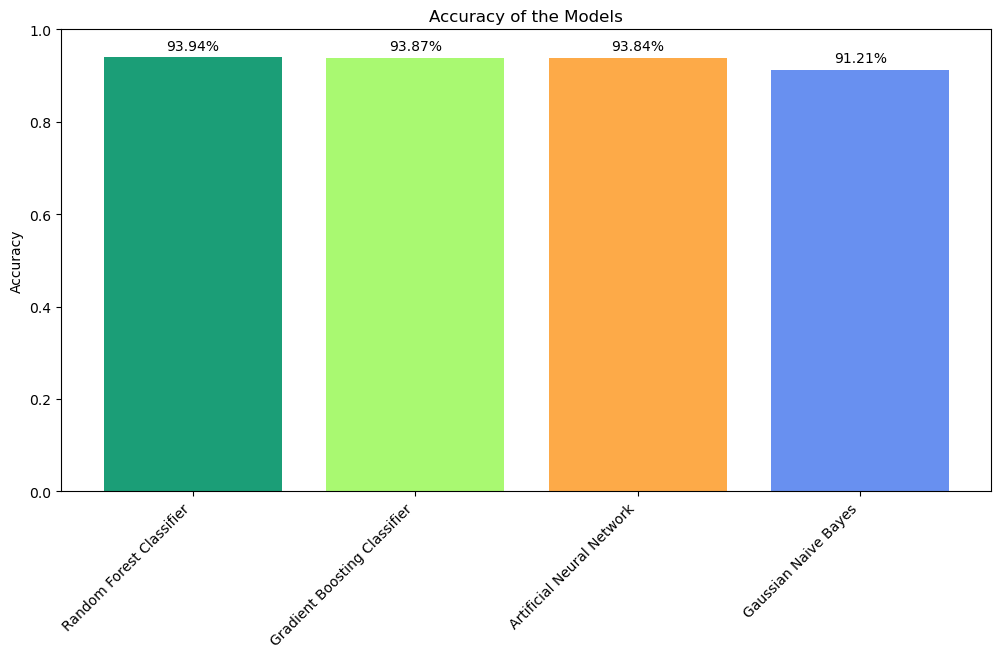

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(sorted_labels, sorted_accuracy_scores, color=custom_colors)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy of the Models')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(sorted_accuracy_scores):
    ax.text(i, v + 0.01, f"{v:.2%}", ha='center', va='bottom')